# NAM Raman — Annotated Peak Assignment Figure
**Purpose:** Plot experimental Raman spectrum vs DFT simulation with key functional group annotations  
**Method:** Mark only ~13 scientifically important peaks to keep the figure publication-ready  

> ⚠️ Run **after** `NAM_Raman_Analysis.ipynb` — requires the processed experimental CSV and `simdata.xlsx`

---
## ⚙️ Step 1 — Configuration

In [11]:
import glob
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

warnings.filterwarnings('ignore')

# ── PATHS ────────────────────────────────────────────────────────────────────
PROJECT_DIR = r"."
OUTPUT_DIR = os.path.join(PROJECT_DIR, 'output_figures')
RANKED_CSV = os.path.join(OUTPUT_DIR, 'ranked_spectra_table.csv')
SIM_FILE = os.path.join(PROJECT_DIR, 'simdata.xlsx')


def resolve_best_processed_csv(output_dir, ranked_csv):
    """Pick best processed CSV from ranking file, fallback to available processed files."""
    candidates = []

    if os.path.exists(ranked_csv):
        try:
            df_ranked = pd.read_csv(ranked_csv)
            if len(df_ranked) > 0 and 'fname' in df_ranked.columns:
                top_fname = str(df_ranked.iloc[0]['fname']).strip()
                stem = os.path.splitext(top_fname)[0]
                candidates.append(os.path.join(output_dir, f'processed_{stem}.csv'))
        except Exception as exc:
            print(f'⚠️ Could not read ranked_spectra_table.csv: {exc}')

    candidates.extend(sorted(glob.glob(os.path.join(output_dir, 'processed_*.csv'))))

    for c in candidates:
        if os.path.exists(c):
            return c

    raise FileNotFoundError(
        f'No processed spectrum CSV found in {output_dir}. Expected files like processed_*.csv'
    )


BEST_EXP_CSV = resolve_best_processed_csv(OUTPUT_DIR, RANKED_CSV)

# ── DFT PARAMETERS ───────────────────────────────────────────────────────────
DFT_SCALE = 0.96
GAUSS_SIGMA = 10  # cm^-1

os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(SIM_FILE):
    raise FileNotFoundError(f'Simulation file not found: {SIM_FILE}')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
})

print('✅ Configuration ready.')
print(f'   Output dir : {OUTPUT_DIR}')
print(f'   Best CSV   : {os.path.basename(BEST_EXP_CSV)}')
print(f'   Sim file   : {os.path.basename(SIM_FILE)}')

✅ Configuration ready.
   Output dir : .\output_figures
   Best CSV   : processed_sec-25_power-80_i-2.csv
   Sim file   : simdata.xlsx


---
## 📋 Step 2 — Define Key Peaks & Functional Group Assignments

In [12]:
# ── Key peaks selected for annotation ────────────────────────────────────────
# Format:  raman_shift (cm⁻¹) : (short_label, full_assignment)
# 'short_label' appears on the plot; 'full_assignment' appears in the legend table

KEY_PEAKS = {
     458: ("Ring def.",          "Ring deformation"),
     489: ("Pyranose skel.",     "Pyranose skeletal"),
     541: ("C–C–O def.",         "C–C–O deformation"),
     830: ("Anomeric C–H",       "Anomeric C–H / glycosidic"),
     872: ("C–O–C str.",         "C–O–C stretch"),
     956: ("Ring breathing",     "Pyranose ring breathing"),
    1024: ("C–O str.",           "C–O stretch"),
    1086: ("C–O str.",           "C–O stretch"),
    1157: ("C–O–C str.",         "C–O–C stretch (glycosidic)"),
    1319: ("Amide III",          "Amide III (N–H bend + C–N str.)"),
    1452: ("CH₂/CH₃ bend",      "CH₂ / CH₃ bending"),
    1546: ("Amide II",           "Amide II (N–H bend + C–N str.)"),
    1701: ("C=O str.",           "C=O stretch (carboxylic acid)"),
}

print(f'✅ {len(KEY_PEAKS)} key peaks defined.')
print(f'\n{"Shift (cm⁻¹)":>14}   {"Short Label":<18}   Full Assignment')
print('-' * 70)
for shift, (short, full) in KEY_PEAKS.items():
    print(f'{shift:>14}   {short:<18}   {full}')

✅ 13 key peaks defined.

  Shift (cm⁻¹)   Short Label          Full Assignment
----------------------------------------------------------------------
           458   Ring def.            Ring deformation
           489   Pyranose skel.       Pyranose skeletal
           541   C–C–O def.           C–C–O deformation
           830   Anomeric C–H         Anomeric C–H / glycosidic
           872   C–O–C str.           C–O–C stretch
           956   Ring breathing       Pyranose ring breathing
          1024   C–O str.             C–O stretch
          1086   C–O str.             C–O stretch
          1157   C–O–C str.           C–O–C stretch (glycosidic)
          1319   Amide III            Amide III (N–H bend + C–N str.)
          1452   CH₂/CH₃ bend         CH₂ / CH₃ bending
          1546   Amide II             Amide II (N–H bend + C–N str.)
          1701   C=O str.             C=O stretch (carboxylic acid)


---
## 📂 Step 3 — Load Experimental Spectrum

In [13]:
df_exp = pd.read_csv(BEST_EXP_CSV)
raman_shift_exp = df_exp.iloc[:, 0].values
intensity_exp   = df_exp.iloc[:, 1].values

# Ensure normalized
if intensity_exp.max() > 0:
    intensity_exp = intensity_exp / intensity_exp.max()

print(f'✅ Experimental spectrum loaded.')
print(f'   Points : {len(raman_shift_exp)}')
print(f'   Range  : {raman_shift_exp.min():.1f} – {raman_shift_exp.max():.1f} cm⁻¹')
print(f'   File   : {os.path.basename(BEST_EXP_CSV)}')

✅ Experimental spectrum loaded.
   Points : 1922
   Range  : 200.8 – 2841.9 cm⁻¹
   File   : processed_sec-25_power-80_i-2.csv


---
## 🔬 Step 4 — Load & Process DFT Simulation

In [14]:
df_sim = pd.read_excel(SIM_FILE)
df_sim.columns = [c.strip() for c in df_sim.columns]

FREQ_COL     = df_sim.columns[0]
ACTIVITY_COL = df_sim.columns[1]

df_sim = df_sim[[FREQ_COL, ACTIVITY_COL]].copy()
df_sim.columns = ['frequency', 'activity']
df_sim = df_sim.dropna()
df_sim = df_sim[df_sim['frequency'] > 0]

# Scale DFT frequencies
df_sim['scaled_freq']   = df_sim['frequency'] * DFT_SCALE
df_sim['norm_activity'] = df_sim['activity'] / df_sim['activity'].max()

# Gaussian broadening onto experimental shift axis
def gaussian_broadening(x_grid, stick_freqs, stick_intensities, sigma=10):
    y = np.zeros_like(x_grid, dtype=float)
    for freq, inten in zip(stick_freqs, stick_intensities):
        y += inten * np.exp(-0.5 * ((x_grid - freq) / sigma) ** 2)
    return y

y_sim_broad = gaussian_broadening(
    raman_shift_exp,
    df_sim['scaled_freq'].values,
    df_sim['norm_activity'].values,
    sigma=GAUSS_SIGMA
)
if y_sim_broad.max() > 0:
    y_sim_broad /= y_sim_broad.max()

raman_shift_sim = raman_shift_exp   # same x-axis after broadening

print(f'✅ DFT simulation loaded and broadened.')
print(f'   Modes      : {len(df_sim)}')
print(f'   Scale      : ×{DFT_SCALE}')
print(f'   σ (Gauss)  : {GAUSS_SIGMA} cm⁻¹')

✅ DFT simulation loaded and broadened.
   Modes      : 499
   Scale      : ×0.96
   σ (Gauss)  : 10 cm⁻¹


---
## 🔎 Step 5 — Helper: Find Nearest Point in Array

In [15]:
def find_nearest(x_array, value):
    """Return index of element in x_array closest to value."""
    return int((np.abs(x_array - value)).argmin())

def local_max_near(x_array, y_array, target, window=15):
    """
    Find the local maximum in y_array within ±window cm⁻¹ of target.
    Returns (x_val, y_val).
    """
    mask = (x_array >= target - window) & (x_array <= target + window)
    if not mask.any():
        idx = find_nearest(x_array, target)
        return x_array[idx], y_array[idx]
    local_y = y_array[mask]
    local_x = x_array[mask]
    best    = np.argmax(local_y)
    return local_x[best], local_y[best]

print('✅ Helper functions ready.')

✅ Helper functions ready.


---
## 📊 Step 6 — Build Peak Annotation Table

In [16]:
annotation_data = []

for nominal_shift, (short_label, full_label) in KEY_PEAKS.items():

    # Find actual experimental local max near this peak
    x_exp_act, y_exp_act = local_max_near(raman_shift_exp, intensity_exp, nominal_shift, window=15)

    # Find actual DFT local max near this peak
    x_sim_act, y_sim_act = local_max_near(raman_shift_sim, y_sim_broad, nominal_shift, window=15)

    annotation_data.append({
        'nominal'     : nominal_shift,
        'short_label' : short_label,
        'full_label'  : full_label,
        'x_exp'       : x_exp_act,
        'y_exp'       : y_exp_act,
        'x_sim'       : x_sim_act,
        'y_sim'       : y_sim_act,
        'delta'       : round(x_exp_act - x_sim_act, 1)
    })

df_annot = pd.DataFrame(annotation_data)
print('✅ Annotation table built.')
print()
print(f'{"Nominal":>8}  {"Exp (cm⁻¹)":>12}  {"Sim (cm⁻¹)":>12}  {"Δ (cm⁻¹)":>10}  Assignment')
print('-' * 72)
for _, r in df_annot.iterrows():
    print(f'{r.nominal:>8.0f}  {r.x_exp:>12.1f}  {r.x_sim:>12.1f}  {r.delta:>+10.1f}  {r.full_label}')

✅ Annotation table built.

 Nominal    Exp (cm⁻¹)    Sim (cm⁻¹)    Δ (cm⁻¹)  Assignment
------------------------------------------------------------------------
     458         458.2         447.3       +10.9  Ring deformation
     489         489.0         503.4       -14.4  Pyranose skeletal
     541         541.0         526.7       +14.3  C–C–O deformation
     830         830.2         815.0       +15.1  Anomeric C–H / glycosidic
     872         871.9         886.9       -14.9  C–O–C stretch
     956         955.9         965.7        -9.8  Pyranose ring breathing
    1024        1024.0        1009.5       +14.5  C–O stretch
    1086        1084.6        1078.3        +6.3  C–O stretch
    1157        1155.4        1156.9        -1.6  C–O–C stretch (glycosidic)
    1319        1319.0        1333.9       -15.0  Amide III (N–H bend + C–N str.)
    1452        1451.8        1437.2       +14.5  CH₂ / CH₃ bending
    1546        1547.9        1532.2       +15.6  Amide II (N–H bend + 

---
## 🖼️ Step 7 — Main Annotated Figure (Publication Style)

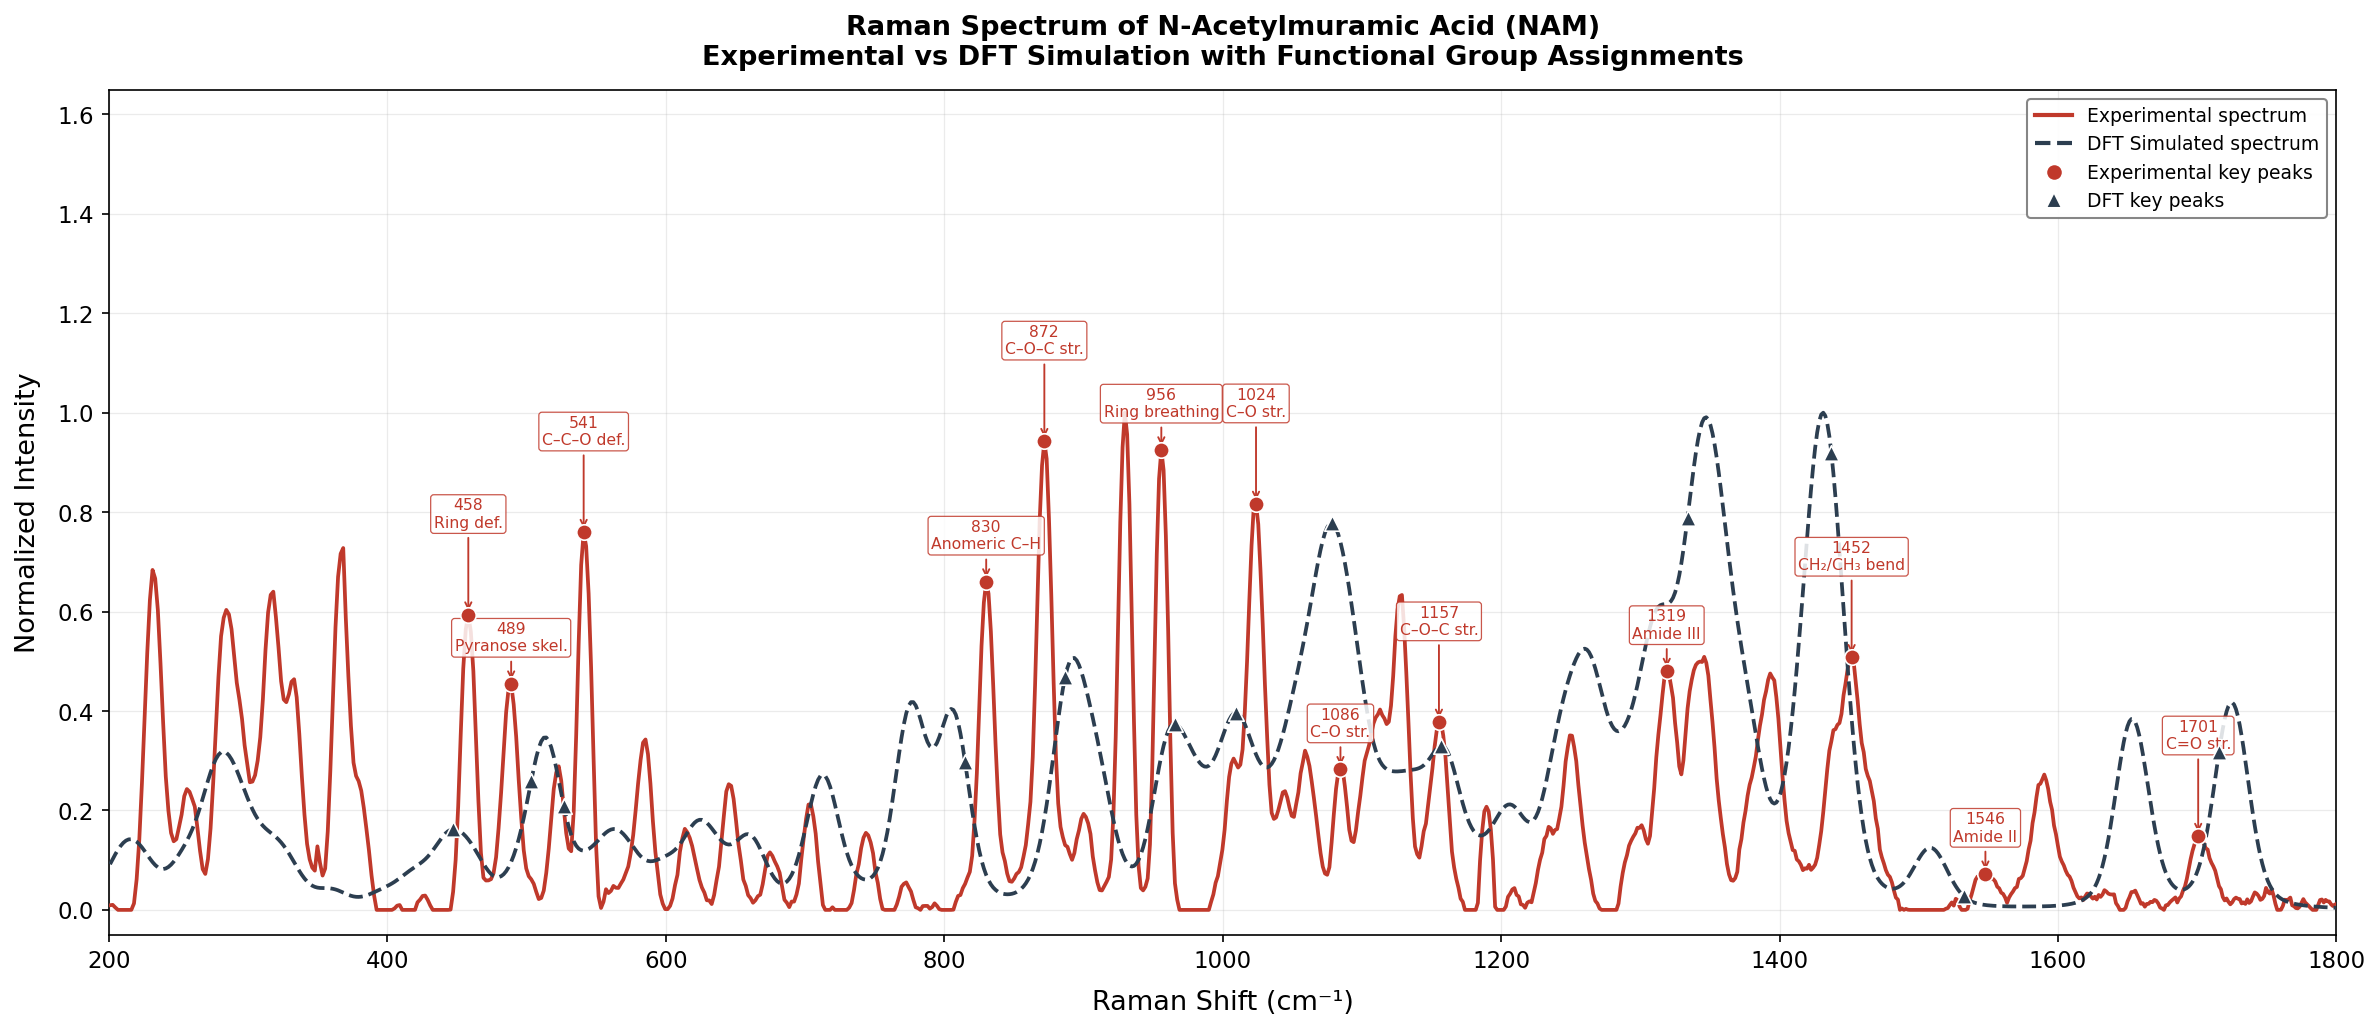

💾 Saved → .\output_figures\fig11_annotated_peak_assignment.png


In [17]:
fig, ax = plt.subplots(figsize=(16, 7))

# ── Spectra lines ─────────────────────────────────────────────────────────────
ax.plot(raman_shift_exp, intensity_exp,
        color='#C0392B', linewidth=1.8, label='Experimental', zorder=3)

ax.plot(raman_shift_sim, y_sim_broad,
        color='#2C3E50', linewidth=1.8, linestyle='--',
        label=f'DFT Simulated (scale={DFT_SCALE}, σ={GAUSS_SIGMA} cm⁻¹)', zorder=3)

# ── Alternate annotation sides to avoid overlap ───────────────────────────────
# Group peaks into 'up' and 'down' alternating by index for cleaner layout
y_step    = 0.12     # vertical offset per annotation tier
tier_up   = [1, 3, 5, 7, 9, 11]    # indices → annotate above
tier_down = [0, 2, 4, 6, 8, 10, 12]

for i, (_, row) in enumerate(df_annot.iterrows()):

    x_e, y_e = row['x_exp'], row['y_exp']
    x_s, y_s = row['x_sim'], row['y_sim']
    label     = f"{row['nominal']:.0f}\n{row['short_label']}"

    # ── Experimental marker + annotation ─────────────────────────────────────
    ax.scatter(x_e, y_e, color='#C0392B', s=55, zorder=6,
               marker='o', edgecolors='white', linewidths=0.8)

    # Alternate above / below
    if i in tier_up:
        y_text = y_e + 0.11
        va     = 'bottom'
        arrow_dy = 0.06
    else:
        y_text = y_e + 0.22    # push further up so long spectrum doesn't collide
        va     = 'bottom'
        arrow_dy = 0.17

    ax.annotate(
        label,
        xy     =(x_e, y_e),
        xytext =(x_e, y_e + arrow_dy),
        textcoords='data',
        arrowprops=dict(arrowstyle='->', color='#C0392B', lw=0.9),
        fontsize  =7.5,
        ha='center', va='bottom',
        color ='#C0392B',
        bbox  =dict(boxstyle='round,pad=0.2', facecolor='white',
                    edgecolor='#C0392B', alpha=0.85, linewidth=0.6)
    )

    # ── DFT marker ────────────────────────────────────────────────────────────
    ax.scatter(x_s, y_s, color='#2C3E50', s=55, zorder=6,
               marker='^', edgecolors='white', linewidths=0.8)

# ── Axis formatting ───────────────────────────────────────────────────────────
ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=13, labelpad=8)
ax.set_ylabel('Normalized Intensity', fontsize=13, labelpad=8)
ax.set_title(
    'Raman Spectrum of N-Acetylmuramic Acid (NAM)\n'
    'Experimental vs DFT Simulation with Functional Group Assignments',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlim(200, 1800)
ax.set_ylim(-0.05, 1.65)
ax.grid(alpha=0.25, linewidth=0.6)

# Custom legend
from matplotlib.lines   import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Line2D([0],[0], color='#C0392B', lw=2,   label='Experimental spectrum'),
    Line2D([0],[0], color='#2C3E50', lw=2,   linestyle='--', label='DFT Simulated spectrum'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#C0392B',
           markersize=8, label='Experimental key peaks'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#2C3E50',
           markersize=8, label='DFT key peaks'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9,
          framealpha=0.95, edgecolor='gray')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig11_annotated_peak_assignment.png')
plt.savefig(save_path, bbox_inches='tight', dpi=200)
plt.show()
print(f'💾 Saved → {save_path}')

---
## 🖼️ Step 8 — Region-Split Figure (Fingerprint + Functional Group Regions)

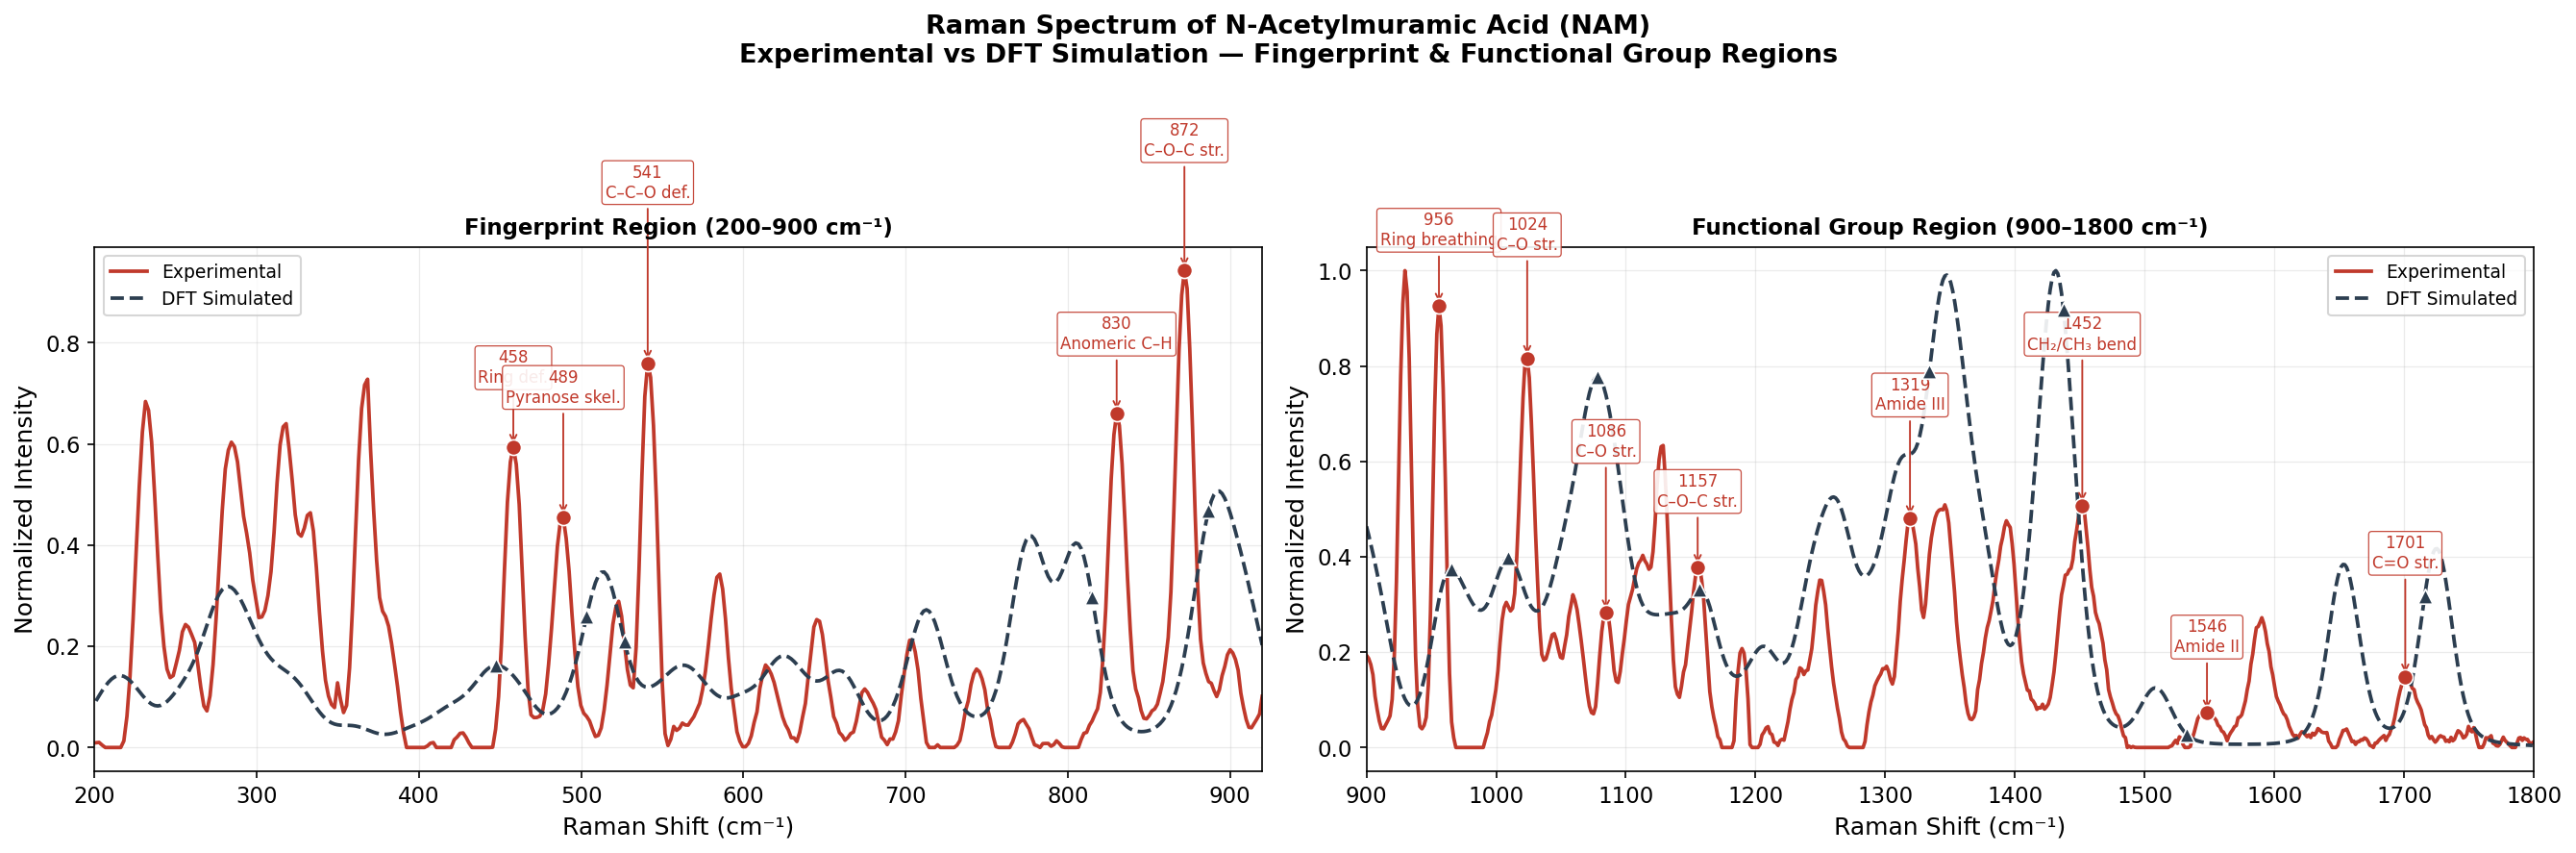

💾 Saved → .\output_figures\fig12_annotated_region_split.png


In [18]:
# Split into two panels for better readability:
# Left  → Fingerprint region  200–900 cm⁻¹
# Right → Functional group    900–1800 cm⁻¹

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
fig.suptitle(
    'Raman Spectrum of N-Acetylmuramic Acid (NAM)\n'
    'Experimental vs DFT Simulation — Fingerprint & Functional Group Regions',
    fontsize=13, fontweight='bold'
)

regions = [
    (ax1, 200,  920,  'Fingerprint Region (200–900 cm⁻¹)'),
    (ax2, 900, 1800,  'Functional Group Region (900–1800 cm⁻¹)'),
]

for ax, xmin, xmax, region_title in regions:

    # Mask data to region
    mask_e = (raman_shift_exp >= xmin) & (raman_shift_exp <= xmax)
    mask_s = (raman_shift_sim >= xmin) & (raman_shift_sim <= xmax)

    x_e = raman_shift_exp[mask_e]
    y_e = intensity_exp[mask_e]
    x_s = raman_shift_sim[mask_s]
    y_s = y_sim_broad[mask_s]

    ax.plot(x_e, y_e, color='#C0392B', lw=1.8, label='Experimental')
    ax.plot(x_s, y_s, color='#2C3E50', lw=1.8, linestyle='--', label='DFT Simulated')

    # Annotate peaks in this region
    region_peaks = df_annot[
        (df_annot['nominal'] >= xmin) & (df_annot['nominal'] <= xmax)
    ]

    for j, (_, row) in enumerate(region_peaks.iterrows()):
        x_ep, y_ep = row['x_exp'], row['y_exp']
        x_sp, y_sp = row['x_sim'], row['y_sim']

        # Exp marker
        ax.scatter(x_ep, y_ep, color='#C0392B', s=60, zorder=6,
                   marker='o', edgecolors='white', linewidths=0.8)

        offset = 0.12 + (j % 3) * 0.10   # stagger annotations
        ax.annotate(
            f"{row['nominal']:.0f}\n{row['short_label']}",
            xy     =(x_ep, y_ep),
            xytext =(x_ep, y_ep + offset),
            textcoords='data',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=0.9),
            fontsize=8, ha='center', va='bottom', color='#C0392B',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='#C0392B', alpha=0.9, linewidth=0.6)
        )

        # DFT marker
        ax.scatter(x_sp, y_sp, color='#2C3E50', s=55, zorder=6,
                   marker='^', edgecolors='white', linewidths=0.8)

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12)
    ax.set_ylabel('Normalized Intensity', fontsize=12)
    ax.set_title(region_title, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=9)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig12_annotated_region_split.png')
plt.savefig(save_path, bbox_inches='tight', dpi=200)
plt.show()
print(f'💾 Saved → {save_path}')

---
## 📋 Step 9 — Peak Assignment Summary Table

In [19]:
df_table = df_annot[['nominal','x_exp','x_sim','delta','full_label']].copy()
df_table.columns = [
    'Nominal (cm⁻¹)',
    'Experimental (cm⁻¹)',
    'DFT Simulated (cm⁻¹)',
    'Δ Exp−Sim (cm⁻¹)',
    'Functional Group Assignment'
]
df_table = df_table.round({'Experimental (cm⁻¹)': 1, 'DFT Simulated (cm⁻¹)': 1, 'Δ Exp−Sim (cm⁻¹)': 1})
df_table.index = range(1, len(df_table) + 1)
df_table.index.name = '#'

print('\n📋 PEAK ASSIGNMENT SUMMARY TABLE')
print('═' * 90)
print(df_table.to_string())
print('═' * 90)
print(f'\nMean |Δ|  = {df_table["Δ Exp−Sim (cm⁻¹)"].abs().mean():.2f} cm⁻¹')
print(f'Max  |Δ|  = {df_table["Δ Exp−Sim (cm⁻¹)"].abs().max():.2f} cm⁻¹')

# Save table
table_csv = os.path.join(OUTPUT_DIR, 'peak_assignment_table.csv')
df_table.to_csv(table_csv)
print(f'\n💾 Saved → {table_csv}')


📋 PEAK ASSIGNMENT SUMMARY TABLE
══════════════════════════════════════════════════════════════════════════════════════════
    Nominal (cm⁻¹)  Experimental (cm⁻¹)  DFT Simulated (cm⁻¹)  Δ Exp−Sim (cm⁻¹)      Functional Group Assignment
#                                                                                                               
1              458                458.2                 447.3              10.9                 Ring deformation
2              489                489.0                 503.4             -14.4                Pyranose skeletal
3              541                541.0                 526.7              14.3                C–C–O deformation
4              830                830.2                 815.0              15.1        Anomeric C–H / glycosidic
5              872                871.9                 886.9             -14.9                    C–O–C stretch
6              956                955.9                 965.7              -9.8      

---
## ✅ Step 10 — Output Summary

In [20]:
print('═' * 60)
print('  NAM PEAK ASSIGNMENT — OUTPUTS')
print('═' * 60)
saved = [
    'fig11_annotated_peak_assignment.png   ← Full spectrum annotated',
    'fig12_annotated_region_split.png      ← Fingerprint + FG regions',
    'peak_assignment_table.csv             ← Assignment table',
]
for s in saved:
    print(f'  ✅ {s}')
print()
print(f'  Peaks annotated : {len(KEY_PEAKS)}')
print(f'  Mean |Δ|        : {df_table["Δ Exp−Sim (cm⁻¹)"].abs().mean():.2f} cm⁻¹')
print('═' * 60)

════════════════════════════════════════════════════════════
  NAM PEAK ASSIGNMENT — OUTPUTS
════════════════════════════════════════════════════════════
  ✅ fig11_annotated_peak_assignment.png   ← Full spectrum annotated
  ✅ fig12_annotated_region_split.png      ← Fingerprint + FG regions
  ✅ peak_assignment_table.csv             ← Assignment table

  Peaks annotated : 13
  Mean |Δ|        : 12.45 cm⁻¹
════════════════════════════════════════════════════════════
